<a href="https://colab.research.google.com/github/valeriaasilva/valeriaasilva/blob/main/Atividade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
np.random.seed(42)

In [4]:
print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [45]:
class Perceptron:
    """
    Implementação do Perceptron de Rosenblatt (1958)

    Um neurônio artificial que aprende a classificar dados linearmente
    separáveis.
    """
    def __init__(self, learning_rate=0.1, n_iterations=100):
        """
        Inicializa o perceptron

        Parâmetros:
        -----------
        learning_rate : float
        Taxa de aprendizado (η) - controla o tamanho dos ajustes nos pesos
        Valores típicos: 0.01 a 1.0

        n_iterations : int
        Número máximo de épocas (passagens completas pelos dados de treino)
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None # Pesos (w) - serão inicializados no treino
        self.bias = None # Bias (b) - será inicializado no treino
        self.errors_history = [] # Histórico de erros por época (para análise)

    def step_function(self, z):
        """
        Função de ativação: Função Degrau (Step Function)

        Converte a soma ponderada em uma decisão binária.
        É a função de ativação mais simples possível.

        Parâmetro:
        ----------
        z : float ou array
        Soma ponderada (produto escalar entre entradas e pesos + bias)

        Retorna:
        --------
        int ou array : 1 se z >= 0, caso contrário 0
        Por que usar essa função?
        - O perceptron original de Rosenblatt usava essa função
        - Produz saídas binárias (0 ou 1)
        - Simples de entender e implementar
        """
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        """
        Faz previsões para novos dados

        Processo:
        1. Calcula o produto escalar entre entradas (X) e pesos (w)
        2. Adiciona o bias (b)
        3. Aplica a função de ativação

        Parâmetro:S
        ----------
        X : array de shape (n_amostras, n_features)
        Dados de entrada para classificar

        Retorna:
        --------
        array : Previsões (0 ou 1) para cada amostra

        Fórmula:
        --------
        ŷ = f(X · w + b)
        onde f é a função degrau
        """
        linear_output = np.dot(X, self.weights) + self.bias
        predictions = self.step_function(linear_output)

        return predictions

    def fit(self, X, y):
        """
        Treina o perceptron usando os dados fornecidos

        Algoritmo de Treinamento:
        1. Inicializar pesos e bias com zeros
        2. Para cada época:
        a. Para cada exemplo (x, y):
        - Calcular previsão ŷ
        - Calcular erro: e = y - ŷ
        - Atualizar pesos: w = w + η * e * x
        - Atualizar bias: b = b + η * e
        3. Repetir até convergir ou atingir n_iterations

        Parâmetros:
        -----------
        X : array de shape (n_amostras, n_features)
        Dados de treinamento (entradas)

        y : array de shape (n_amostras,)
        Rótulos verdadeiros (saídas esperadas: 0 ou 1)

        Retorna:
        --------
        self : objeto Perceptron treinado
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Imprimir estado inicial
        print(f"🎯 Iniciando treinamento...")
        print(f" Pesos iniciais: {self.weights}")
        print(f" Bias inicial: {self.bias}")
        print(f" Taxa de aprendizado: {self.learning_rate}")
        print(f" Número de amostras: {n_samples}")
        print("-" * 50)

        # Passo 2: Loop de treinamento (épocas)
        for epoch in range(self.n_iterations):
            errors = 0 # Contador de erros nesta época

            # Para cada exemplo de treinamento
            for idx, x_i in enumerate(X):
                prediction = self.predict(x_i.reshape(1, -1))[0]

                # Calcular erro
                error = y[idx] - prediction

                # Atualizar pesos se houve erro
                if error != 0:
                    # Regra de atualização do perceptron
                    update = self.learning_rate * error
                    self.weights += update * x_i
                    self.bias += update
                    errors += 1

            # Armazenar número de erros desta época
            self.errors_history.append(errors)

            # Mostrar progresso a cada 10 épocas
            if (epoch + 1) % 10 == 0:
                print(f"Época {epoch + 1:3d} | Erros: {errors:2d} | "
                      f"Pesos: {self.weights} | Bias: {self.bias:.4f}")

            # Critério de parada: se não houver erros, convergiu
            if errors == 0:
                print(f"\n✅ Convergência alcançada na época {epoch + 1}!")
                print(f" Pesos finais: {self.weights}")
                print(f" Bias final: {self.bias:.4f}")
                break

        # Se saiu do loop sem convergir
        if errors > 0:
            print(f"\n⚠ Treinamento finalizado sem convergência completa")
            print(f" Ainda havia {errors} erros na última época")

        return self

In [29]:
print("\n" + "="*50)
print("CLASSE PERCEPTRON IMPLEMENTADA COM SUCESSO!")
print("="*50)


CLASSE PERCEPTRON IMPLEMENTADA COM SUCESSO!


In [31]:
print("\n" + "="*60)
print("EXPERIMENTO 1: PORTA LÓGICA AND")
print("="*60)



EXPERIMENTO 1: PORTA LÓGICA AND


In [36]:
X_and = np.array([
 [0, 0], # Entrada 1
 [0, 1], # Entrada 2
 [1, 0], # Entrada 3
 [1, 1] # Entrada 4
])

In [37]:
y_and = np.array([0, 0, 0, 1])

In [38]:
print("\n📊 Dataset AND:")
print("Entradas (X):")
print(X_and)
print("\nSaídas esperadas (y):")
print(y_and)
print("\n" + "-"*60)



📊 Dataset AND:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 0 0 1]

------------------------------------------------------------


In [39]:
perceptron_and = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_and.fit(X_and, y_and)

🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.2 0.1]
 Bias final: -0.2000


In [40]:
print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)



------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------


In [41]:
predictions_and = perceptron_and.predict(X_and)


In [46]:
print("\n🎯 Comparação: Esperado vs Previsto")
print("-"*40)
for i in range(len(X_and)):
 print(f"Entrada: {X_and[i]} | Esperado: {y_and[i]} | "
 f"Previsto: {predictions_and[i]} | "
 f"{'✅ CORRETO' if y_and[i] == predictions_and[i] else '❌ ERRADO'}")


🎯 Comparação: Esperado vs Previsto
----------------------------------------
Entrada: [0 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [0 1] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [1 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [1 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO


In [47]:
accuracy_and = np.mean(predictions_and == y_and) * 100
print(f"\n🎯 Acurácia: {accuracy_and:.2f}%")


🎯 Acurácia: 100.00%


In [56]:
def plot_decision_boundary(X, y, perceptron, title):
    """
    Plota os pontos de dados e a fronteira de decisão do perceptron

    A fronteira de decisão é a linha que separa as duas classes.
    Matematicamente: w₁x₁ + w₂x₂ + b = 0
    """
    # Configura o gráfico
    plt.figure(figsize=(10, 7))


    plt.scatter(X[y == 0, 0], X[y == 0, 1],
                color='red', marker='o', s=200,
                edgecolors='black', linewidths=2,
                label='Classe 0', alpha=0.7)


    plt.scatter(X[y == 1, 0], X[y == 1, 1],
                color='green', marker='*', s=400,
                edgecolors='black', linewidths=2,
                label='Classe 1', alpha=0.7)

    x1_boundary = np.linspace(-0.5, 1.5, 100)

    # Calcular x₂ correspondentes
    # Evitar divisão por zero
    if perceptron.weights[1] != 0:
        x2_boundary = -(perceptron.weights[0] * x1_boundary + perceptron.bias) / perceptron.weights[1]
        plt.plot(x1_boundary, x2_boundary, 'b-', linewidth=2,
                 label='Fronteira de Decisão')

    # Configurações do gráfico
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel('x₁ (Entrada 1)', fontsize=14, fontweight='bold')
    plt.ylabel('x₂ (Entrada 2)', fontsize=14, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)

    # Adicionar anotações com os pesos
    equation = f'Fronteira: {perceptron.weights[0]:.2f}x₁ + {perceptron.weights[1]:.2f}x₂ + {perceptron.bias:.2f} = 0'
    plt.text(0.02, 0.98, equation, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.tight_layout()
    plt.show()

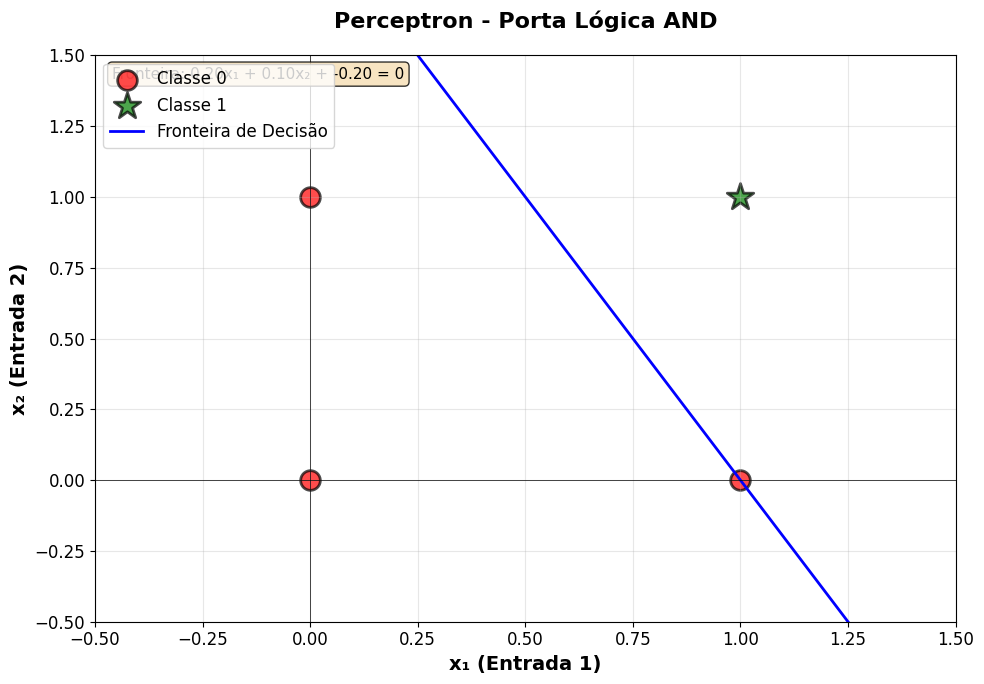


📊 Interpretação do Gráfico:
------------------------------------------------------------
• A linha azul é a FRONTEIRA DE DECISÃO
• Tudo acima/à direita da linha: perceptron prevê 1
• Tudo abaixo/à esquerda da linha: perceptron prevê 0
• Círculos vermelhos: classe 0 (AND retorna 0)
• Estrelas verdes: classe 1 (AND retorna 1)

✅ Note que a linha separa perfeitamente as duas classes!


In [55]:
# Plotar resultado para AND
plot_decision_boundary(X_and, y_and, perceptron_and,
                       'Perceptron - Porta Lógica AND')
print("\n📊 Interpretação do Gráfico:")
print("-" * 60)
print("• A linha azul é a FRONTEIRA DE DECISÃO")
print("• Tudo acima/à direita da linha: perceptron prevê 1")
print("• Tudo abaixo/à esquerda da linha: perceptron prevê 0")
print("• Círculos vermelhos: classe 0 (AND retorna 0)")
print("• Estrelas verdes: classe 1 (AND retorna 1)")
print("\n✅ Note que a linha separa perfeitamente as duas classes!")

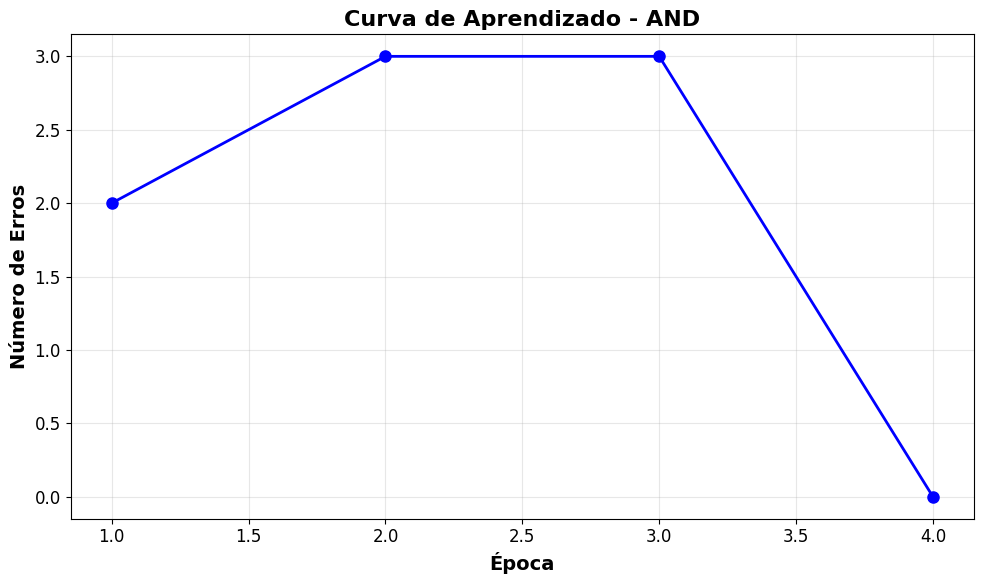


📊 Análise da Curva de Aprendizado:
------------------------------------------------------------
• Número total de épocas: 4
• Erros na época 1: 2
• Erros na última época: 0
• Convergência: SIM ✅

💡 O que isso significa:
 O perceptron começou errando algumas previsões,
 mas aprendeu rapidamente e chegou a zero erros.
 Isso acontece porque AND é linearmente separável!


In [57]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_and.errors_history) + 1),
 perceptron_and.errors_history,
 marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel('Época', fontsize=14, fontweight='bold')
plt.ylabel('Número de Erros', fontsize=14, fontweight='bold')
plt.title('Curva de Aprendizado - AND', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📊 Análise da Curva de Aprendizado:")
print("-" * 60)
print(f"• Número total de épocas: {len(perceptron_and.errors_history)}")
print(f"• Erros na época 1: {perceptron_and.errors_history[0]}")
print(f"• Erros na última época: {perceptron_and.errors_history[-1]}")
print(f"• Convergência: {'SIM ✅' if perceptron_and.errors_history[-1] == 0
else 'NÃO ❌'}")
print("\n💡 O que isso significa:")
print(" O perceptron começou errando algumas previsões,")
print(" mas aprendeu rapidamente e chegou a zero erros.")
print(" Isso acontece porque AND é linearmente separável!")

In [59]:
print("\n" + "="*60)
print("EXPERIMENTO 2: PORTA LÓGICA OR")
print("="*60)



EXPERIMENTO 2: PORTA LÓGICA OR


In [60]:
X_or = np.array([
 [0, 0],
 [0, 1],
 [1, 0],
 [1, 1]
])


In [61]:
y_or = np.array([0, 1, 1, 1])

In [62]:
print("\n📊 Dataset OR:")
print("Entradas (X):")
print(X_or)
print("\nSaídas esperadas (y):")
print(y_or)
print("\n" + "-"*60)



📊 Dataset OR:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 1 1 1]

------------------------------------------------------------


In [63]:
perceptron_or = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_or.fit(X_or, y_or)

🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.1 0.1]
 Bias final: -0.1000


In [64]:
print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)


------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------


In [65]:
predictions_or = perceptron_or.predict(X_or)

In [66]:
print("\n🎯 Comparação: Esperado vs Previsto")
print("-"*40)
for i in range(len(X_or)):
 print(f"Entrada: {X_or[i]} | Esperado: {y_or[i]} | "
 f"Previsto: {predictions_or[i]} | "
 f"{'✅ CORRETO' if y_or[i] == predictions_or[i] else '❌ ERRADO'}")


🎯 Comparação: Esperado vs Previsto
----------------------------------------
Entrada: [0 0] | Esperado: 0 | Previsto: 0 | ✅ CORRETO
Entrada: [0 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO
Entrada: [1 0] | Esperado: 1 | Previsto: 1 | ✅ CORRETO
Entrada: [1 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO



🎯 Acurácia: 100.00%


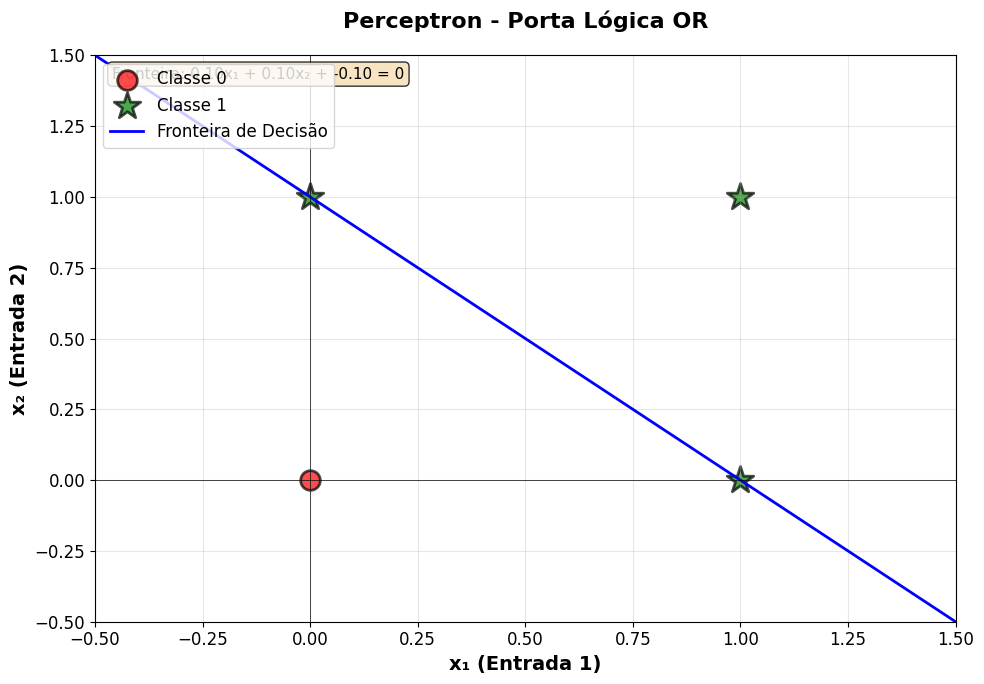

In [70]:
accuracy_or = np.mean(predictions_or == y_or) * 100
print(f"\n🎯 Acurácia: {accuracy_or:.2f}%")
plot_decision_boundary(X_or, y_or, perceptron_or,
 'Perceptron - Porta Lógica OR')

In [71]:
print("\n" + "="*60)
print("COMPARAÇÃO: AND vs OR")
print("="*60)
print("\n📊 Pesos Finais:")
print("-" * 40)
print(f"AND - Peso 1: {perceptron_and.weights[0]:.4f}")
print(f"AND - Peso 2: {perceptron_and.weights[1]:.4f}")
print(f"AND - Bias: {perceptron_and.bias:.4f}")
print()
print(f"OR - Peso 1: {perceptron_or.weights[0]:.4f}")
print(f"OR - Peso 2: {perceptron_or.weights[1]:.4f}")
print(f"OR - Bias: {perceptron_or.bias:.4f}")
print("\n💡 Interpretação:")
print("-" * 60)
print("• Para AND: pesos maiores e bias mais negativo")
print(" → Precisa de MAIS evidência para ativar (ambas entradas)")
print()
print("• Para OR: pesos menores e bias menos negativo")
print(" → Precisa de MENOS evidência para ativar (qualquer entrada)")
print()
print("• Ambos convergem rapidamente porque são linearmente separáveis!")


COMPARAÇÃO: AND vs OR

📊 Pesos Finais:
----------------------------------------
AND - Peso 1: 0.2000
AND - Peso 2: 0.1000
AND - Bias: -0.2000

OR - Peso 1: 0.1000
OR - Peso 2: 0.1000
OR - Bias: -0.1000

💡 Interpretação:
------------------------------------------------------------
• Para AND: pesos maiores e bias mais negativo
 → Precisa de MAIS evidência para ativar (ambas entradas)

• Para OR: pesos menores e bias menos negativo
 → Precisa de MENOS evidência para ativar (qualquer entrada)

• Ambos convergem rapidamente porque são linearmente separáveis!


In [72]:
print("\n" + "="*60)
print("EXPERIMENTO 3: PORTA LÓGICA XOR")
print("="*60)



EXPERIMENTO 3: PORTA LÓGICA XOR


In [74]:
x_xor = np.array([
 [0, 0],
 [0, 1],
 [1, 0],
 [1, 1]
])


In [75]:
y_xor = np.array([0, 1, 1, 0])

In [79]:
print("\n📊 Dataset XOR:")
print("Entradas (X):")
print(x_xor)
print("\nSaídas esperadas (y):")
print(y_xor)
print("\n⚠ ATENÇÃO: XOR é NÃO linearmente separável!")
print(" O perceptron NÃO deve conseguir aprender este padrão.")
print("\n" + "-"*60)


📊 Dataset XOR:
Entradas (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Saídas esperadas (y):
[0 1 1 0]

⚠ ATENÇÃO: XOR é NÃO linearmente separável!
 O perceptron NÃO deve conseguir aprender este padrão.

------------------------------------------------------------


In [78]:
perceptron_xor = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_xor.fit(x_xor, y_xor)
print("\n" + "-"*60)
print("📈 RESULTADOS DO TREINAMENTO")
print("-"*60)

🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------
Época  10 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  20 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  30 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  40 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  50 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  60 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  70 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  80 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época  90 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000
Época 100 | Erros:  4 | Pesos: [-0.1  0. ] | Bias: 0.0000

⚠ Treinamento finalizado sem convergência completa
 Ainda havia 4 erros na última época

------------------------------------------------------------
📈 RESULTADOS DO TREINAMENTO
------------------------------------------------------------


In [81]:
predictions_xor = perceptron_xor.predict(x_xor)
print("\n🎯 Comparação: Esperado vs Previsto")
print("-"*40)
for i in range(len(x_xor)):
 print(f"Entrada: {x_xor[i]} | Esperado: {y_xor[i]} | "
 f"Previsto: {predictions_xor[i]} | "
 f"{'✅ CORRETO' if y_xor[i] == predictions_xor[i] else '❌ ERRADO'}")


🎯 Comparação: Esperado vs Previsto
----------------------------------------
Entrada: [0 0] | Esperado: 0 | Previsto: 1 | ❌ ERRADO
Entrada: [0 1] | Esperado: 1 | Previsto: 1 | ✅ CORRETO
Entrada: [1 0] | Esperado: 1 | Previsto: 0 | ❌ ERRADO
Entrada: [1 1] | Esperado: 0 | Previsto: 0 | ✅ CORRETO


In [82]:
accuracy_xor = np.mean(predictions_xor == y_xor) * 100
print(f"\n🎯 Acurácia: {accuracy_xor:.2f}%")
if accuracy_xor < 100:
 print("\n⚠ FALHA ESPERADA!")
 print(" O perceptron não conseguiu aprender XOR perfeitamente.")



🎯 Acurácia: 50.00%

⚠ FALHA ESPERADA!
 O perceptron não conseguiu aprender XOR perfeitamente.


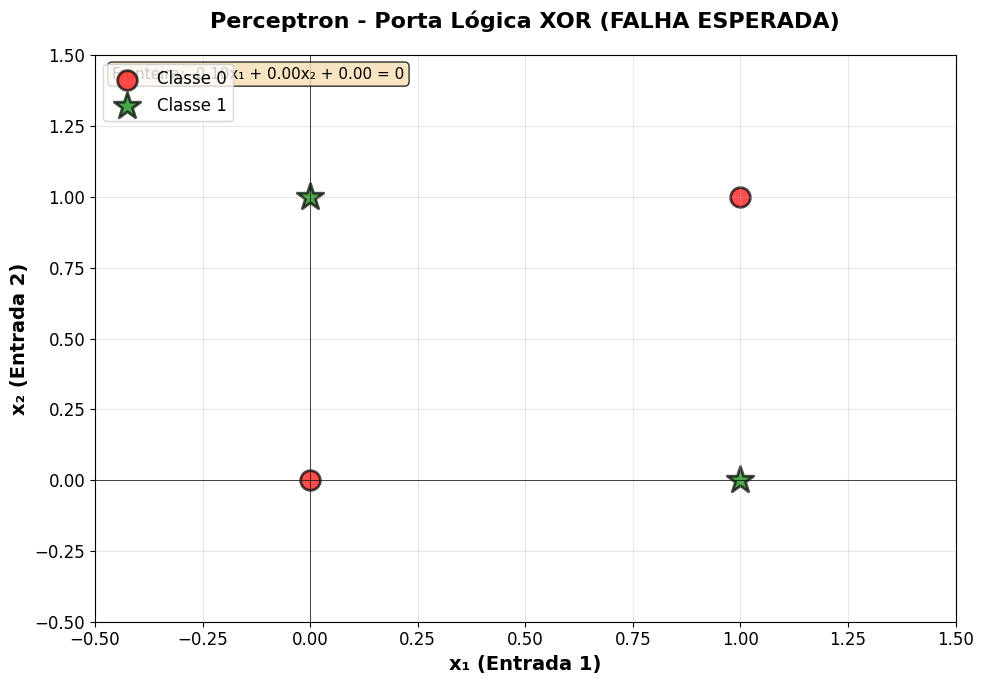

In [84]:
plot_decision_boundary(x_xor, y_xor, perceptron_xor,
 'Perceptron - Porta Lógica XOR (FALHA ESPERADA)')

In [85]:
print("\n" + "="*60)
print("POR QUE O PERCEPTRON FALHA NO XOR?")
print("="*60)
print("\n🔍 Análise Geométrica:")
print("-" * 60)
print("1. O perceptron só consegue desenhar LINHAS RETAS")
print("2. XOR precisa de uma separação em FORMATO DE CRUZ ou CURVA")
print("3. Matematicamente: XOR é NÃO linearmente separável")
print()
print("Visualizando:")
print()
print(" x₂")
print(" 1│ [0] [1]")
print(" │")
print(" 0│ [0] [1]")
print(" └────────────── x₁")
print(" 0 1")
print()
print("Impossível separar com uma linha reta!")
print()
print("💡 Solução Histórica:")
print(" • 1969: Minsky & Papert publicam 'Perceptrons'")
print(" • Provam matematicamente a limitação")
print(" • Causa o primeiro 'inverno da IA'")
print(" • Solução: Redes Neurais Multicamadas (1986)")


POR QUE O PERCEPTRON FALHA NO XOR?

🔍 Análise Geométrica:
------------------------------------------------------------
1. O perceptron só consegue desenhar LINHAS RETAS
2. XOR precisa de uma separação em FORMATO DE CRUZ ou CURVA
3. Matematicamente: XOR é NÃO linearmente separável

Visualizando:

 x₂
 1│ [0] [1]
 │
 0│ [0] [1]
 └────────────── x₁
 0 1

Impossível separar com uma linha reta!

💡 Solução Histórica:
 • 1969: Minsky & Papert publicam 'Perceptrons'
 • Provam matematicamente a limitação
 • Causa o primeiro 'inverno da IA'
 • Solução: Redes Neurais Multicamadas (1986)


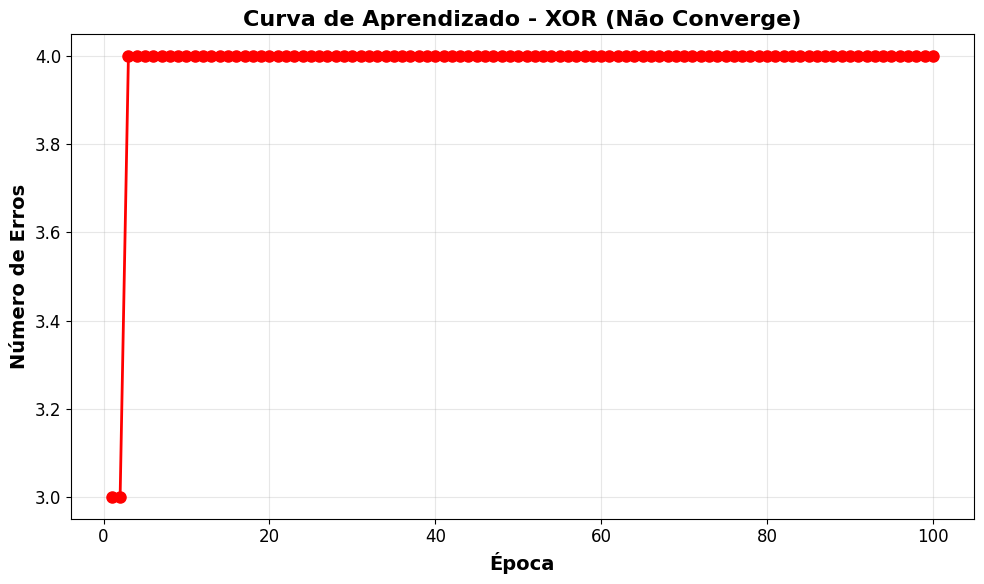


📊 Análise da Curva:
------------------------------------------------------------
• Note que o número de erros NÃO chega a zero
• O perceptron fica 'preso' tentando aprender
• Não há configuração de pesos que resolva XOR com uma linha
• Este foi um resultado CRUCIAL na história da IA


In [86]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_xor.errors_history) + 1),
 perceptron_xor.errors_history,
 marker='o', linewidth=2, markersize=8, color='red')
plt.xlabel('Época', fontsize=14, fontweight='bold')
plt.ylabel('Número de Erros', fontsize=14, fontweight='bold')
plt.title('Curva de Aprendizado - XOR (Não Converge)',
 fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📊 Análise da Curva:")
print("-" * 60)
print("• Note que o número de erros NÃO chega a zero")
print("• O perceptron fica 'preso' tentando aprender")
print("• Não há configuração de pesos que resolva XOR com uma linha")
print("• Este foi um resultado CRUCIAL na história da IA")

In [87]:
print("\n" + "="*60)
print("EXPERIMENTO 4: IMPACTO DA TAXA DE APRENDIZADO")
print("="*60)



EXPERIMENTO 4: IMPACTO DA TAXA DE APRENDIZADO


In [89]:
learning_rates = [0.01, 0.1, 1.0]
colors = ['blue', 'green', 'red']
plt.figure(figsize=(14, 5))
for idx, lr in enumerate(learning_rates):
 print(f"\n{'='*60}")
 print(f"Taxa de Aprendizado: {lr}")
 print(f"{'='*60}")


Taxa de Aprendizado: 0.01

Taxa de Aprendizado: 0.1

Taxa de Aprendizado: 1.0


<Figure size 1400x500 with 0 Axes>

In [92]:
perceptron_lr = Perceptron(learning_rate=lr, n_iterations=100)

In [93]:
perceptron_lr.fit(X_and, y_and)


🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 1.0
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 6!
 Pesos finais: [2. 1.]
 Bias final: -3.0000


(-0.5, 5.0)

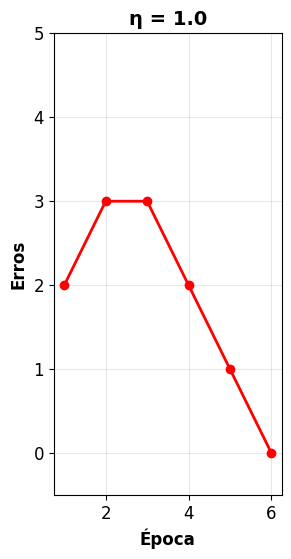

In [97]:
plt.subplot(1, 3, idx + 1)
plt.plot(range(1, len(perceptron_lr.errors_history) + 1),
 perceptron_lr.errors_history,
 marker='o', linewidth=2, markersize=6, color=colors[idx])
plt.xlabel('Época', fontsize=12, fontweight='bold')
plt.ylabel('Erros', fontsize=12, fontweight='bold')
plt.title(f'η = {lr}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 5)

In [98]:
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

In [99]:
print("\n" + "="*60)
print("ANÁLISE DOS RESULTADOS")
print("="*60)
print("\n🐌 Taxa Baixa (η = 0.01):")
print("-" * 60)
print("• Convergência LENTA")
print("• Passos muito pequenos")
print("• Seguro, mas ineficiente")
print("• Use quando: dados ruidosos ou instabilidade")
print("\n⚖ Taxa Moderada (η = 0.1):")
print("-" * 60)
print("• EQUILÍBRIO ideal")
print("• Convergência rápida e estável")
print("• Valor PADRÃO recomendado")
print("• Use quando: situação típica")
print("\n🚀 Taxa Alta (η = 1.0):")
print("-" * 60)
print("• Convergência muito rápida OU instabilidade")
print("• Passos grandes podem 'pular' a solução")
print("• Pode oscilar sem convergir em problemas complexos")
print("• Use quando: problema simples e quer velocidade")
print("\n💡 Regra Prática:")
print("-" * 60)
print("• Comece com η = 0.1 (valor padrão)")
print("• Se não convergir: reduza (ex: 0.01)")
print("• Se convergir muito devagar: aumente (ex: 0.5)")
print("• Problemas difíceis: taxas menores (0.001 - 0.1)")
print("• Problemas simples: taxas maiores (0.1 - 1.0)")


ANÁLISE DOS RESULTADOS

🐌 Taxa Baixa (η = 0.01):
------------------------------------------------------------
• Convergência LENTA
• Passos muito pequenos
• Seguro, mas ineficiente
• Use quando: dados ruidosos ou instabilidade

⚖ Taxa Moderada (η = 0.1):
------------------------------------------------------------
• EQUILÍBRIO ideal
• Convergência rápida e estável
• Valor PADRÃO recomendado
• Use quando: situação típica

🚀 Taxa Alta (η = 1.0):
------------------------------------------------------------
• Convergência muito rápida OU instabilidade
• Passos grandes podem 'pular' a solução
• Pode oscilar sem convergir em problemas complexos
• Use quando: problema simples e quer velocidade

💡 Regra Prática:
------------------------------------------------------------
• Comece com η = 0.1 (valor padrão)
• Se não convergir: reduza (ex: 0.01)
• Se convergir muito devagar: aumente (ex: 0.5)
• Problemas difíceis: taxas menores (0.001 - 0.1)
• Problemas simples: taxas maiores (0.1 - 1.0)


In [100]:
print("\n" + "="*60)
print("TABELA COMPARATIVA: IMPACTO DA TAXA DE APRENDIZADO")
print("="*60)
results = []


TABELA COMPARATIVA: IMPACTO DA TAXA DE APRENDIZADO


In [101]:
for lr in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
 perceptron_test = Perceptron(learning_rate=lr, n_iterations=100)
 perceptron_test.fit(X_and, y_and)

 results.append({
 'Taxa': lr,
 'Épocas': len(perceptron_test.errors_history),
 'Convergiu': perceptron_test.errors_history[-1] == 0,
 'Erros_Finais': perceptron_test.errors_history[-1]
 })
print("\n{:<10} {:<10} {:<12} {:<15}".format(
 "Taxa (η)", "Épocas", "Convergiu?", "Erros Finais"
))
print("-" * 60)
for r in results:
 print("{:<10} {:<10} {:<12} {:<15}".format(
 r['Taxa'],
 r['Épocas'],
 "✅ Sim" if r['Convergiu'] else "❌ Não",
 r['Erros_Finais']
 ))
print("\n" + "="*60)


🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.001
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 6!
 Pesos finais: [0.002 0.001]
 Bias final: -0.0030
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.01
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 6!
 Pesos finais: [0.02 0.01]
 Bias final: -0.0300
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.05
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.1  0.05]
 Bias final: -0.1000
🎯 Iniciando treinamento...
 Pesos iniciais: [0. 0.]
 Bias inicial: 0
 Taxa de aprendizado: 0.1
 Número de amostras: 4
--------------------------------------------------

✅ Convergência alcançada na época 4!
 Pesos finais: [0.2 0.

In [102]:
print("\n" + "="*60)
print("DO PERCEPTRON AO DEEP LEARNING")
print("="*60)



DO PERCEPTRON AO DEEP LEARNING


In [103]:
print(""" 📜 LINHA DO TEMPO E EVOLUÇÃO:
1943 - McCulloch & Pitts
│ Primeiro modelo matemático de neurônio
│
1958 - Rosenblatt
│ PERCEPTRON (o que implementamos hoje!)
│ ✅ Aprende padrões lineares
│ ❌ Não resolve XOR
│
1969 - Minsky & Papert
│ Livro "Perceptrons" → Primeiro Inverno da IA
│ Provam limitações matemáticas
│
1986 - Rumelhart, Hinton & Williams
│ BACKPROPAGATION + Redes Multicamadas
│ ✅ Resolve XOR com camada oculta
│ ✅ Funções não-lineares
│
2012 - Krizhevsky (AlexNet)
│ Deep Learning vence ImageNet
│ Revolução da IA moderna
│
2017-2024 - Era Transformer
│ GPT, BERT, ChatGPT, Gemini
│ Bilhões de parâmetros
│ Mas o PRINCÍPIO é o mesmo! ⚡
""")


 📜 LINHA DO TEMPO E EVOLUÇÃO:
1943 - McCulloch & Pitts
│ Primeiro modelo matemático de neurônio
│
1958 - Rosenblatt
│ PERCEPTRON (o que implementamos hoje!)
│ ✅ Aprende padrões lineares
│ ❌ Não resolve XOR
│
1969 - Minsky & Papert
│ Livro "Perceptrons" → Primeiro Inverno da IA
│ Provam limitações matemáticas
│
1986 - Rumelhart, Hinton & Williams
│ BACKPROPAGATION + Redes Multicamadas
│ ✅ Resolve XOR com camada oculta
│ ✅ Funções não-lineares
│
2012 - Krizhevsky (AlexNet)
│ Deep Learning vence ImageNet
│ Revolução da IA moderna
│
2017-2024 - Era Transformer
│ GPT, BERT, ChatGPT, Gemini
│ Bilhões de parâmetros
│ Mas o PRINCÍPIO é o mesmo! ⚡



In [104]:
print("🧠 Como o Perceptron se Conecta com Redes Modernas:")
print("-" * 60)
print()
print("1. NEURÔNIO BÁSICO (Perceptron):")
print(" ŷ = f(w·x + b)")
print()
print("2. REDE NEURAL MULTICAMADAS:")
print(" • Empilhar múltiplos perceptrons")
print(" • Adicionar camadas ocultas")
print(" • Resolver problemas não-lineares (XOR!)")
print()
print("3. DEEP LEARNING:")
print(" • Muitas camadas (10, 50, 100+)")
print(" • Milhões/bilhões de pesos")
print(" • Mesma regra de atualização (gradient descent)")
print()
print("💡 CONCLUSÃO:")
print(" O perceptron é o 'átomo' das redes neurais modernas!")
print(" Tudo que você aprendeu hoje escala para GPT, BERT, etc.")

🧠 Como o Perceptron se Conecta com Redes Modernas:
------------------------------------------------------------

1. NEURÔNIO BÁSICO (Perceptron):
 ŷ = f(w·x + b)

2. REDE NEURAL MULTICAMADAS:
 • Empilhar múltiplos perceptrons
 • Adicionar camadas ocultas
 • Resolver problemas não-lineares (XOR!)

3. DEEP LEARNING:
 • Muitas camadas (10, 50, 100+)
 • Milhões/bilhões de pesos
 • Mesma regra de atualização (gradient descent)

💡 CONCLUSÃO:
 O perceptron é o 'átomo' das redes neurais modernas!
 Tudo que você aprendeu hoje escala para GPT, BERT, etc.


In [105]:
print("\n" + "="*60)
print("COMO RESOLVER XOR: VISÃO GERAL")
print("="*60)
print(""" ❌ Perceptron Simples (1 camada):

 x₁ ─────┐
 ├──→ Σ ──→ f() ──→ ŷ
 x₂ ──
 Pode:
 • AND, OR, NOT
 • Qualquer função linearmente separável

 Não Pode:
 • XOR
 • Problemas complexos
✅ Rede Neural Multicamadas (2+ camadas):

 Camada Oculta Camada Saída
 x₁ ─────┬──→ h₁ ─────┐
 │ ├──→ ŷ
 x₂ ─────┼──→ h₂ ─────┘
 │
 └──→ h₃

 Pode:
 • XOR ✓
 • Funções não-lineares complexas ✓
 • Classificação de imagens ✓
 • Reconhecimento de fala ✓
🔑 DIFERENÇA FUNDAMENTAL:

 • Camada oculta cria REPRESENTAÇÕES INTERMEDIÁRIAS
 • Neurônios ocultos aprendem FEATURES úteis
 • Combina múltiplas fronteiras lineares
 • Resultado: capacidade de modelar NÃO-LINEARIDADE
 📚 Para Aprender Mais:

 • Próximas aulas: implementaremos MLP (Multi-Layer Perceptron)
 • Veremos backpropagation (como treinar redes profundas)
 • Aplicações práticas: MNIST, classificação de imagens
""")


COMO RESOLVER XOR: VISÃO GERAL
 ❌ Perceptron Simples (1 camada):

 x₁ ─────┐
 ├──→ Σ ──→ f() ──→ ŷ
 x₂ ──
 Pode:
 • AND, OR, NOT
 • Qualquer função linearmente separável

 Não Pode:
 • XOR
 • Problemas complexos
✅ Rede Neural Multicamadas (2+ camadas):

 Camada Oculta Camada Saída
 x₁ ─────┬──→ h₁ ─────┐
 │ ├──→ ŷ
 x₂ ─────┼──→ h₂ ─────┘
 │
 └──→ h₃

 Pode:
 • XOR ✓
 • Funções não-lineares complexas ✓
 • Classificação de imagens ✓
 • Reconhecimento de fala ✓
🔑 DIFERENÇA FUNDAMENTAL:

 • Camada oculta cria REPRESENTAÇÕES INTERMEDIÁRIAS
 • Neurônios ocultos aprendem FEATURES úteis
 • Combina múltiplas fronteiras lineares
 • Resultado: capacidade de modelar NÃO-LINEARIDADE
 📚 Para Aprender Mais:
 
 • Próximas aulas: implementaremos MLP (Multi-Layer Perceptron)
 • Veremos backpropagation (como treinar redes profundas)
 • Aplicações práticas: MNIST, classificação de imagens



In [106]:
print("\n" + "="*60)
print("QUANDO USAR (E NÃO USAR) PERCEPTRON")
print("="*60)
print("\n✅ USE PERCEPTRON QUANDO:")
print("-" * 60)
print("• Problema é linearmente separável")
print("• Classificação binária simples")
print("• Poucos features (< 100)")
print("• Precisa de modelo interpretável")
print("• Dados pequenos/limitados")
print("• Quer entender fundamentos de ML")
print()
print("Exemplos:")
print(" → Classificar emails (spam: sim/não) com palavras-chave")
print(" → Aprovar crédito baseado em 3-4 variáveis simples")
print(" → Detectar fraude com regras lineares")
print("\n❌ NÃO USE PERCEPTRON QUANDO:")
print("-" * 60)
print("• Problema é não-linear (ex: XOR)")
print("• Múltiplas classes (>2)")
print("• Dados complexos (imagens, áudio, texto)")
print("• Padrões sutis e hierárquicos")
print("• Grande volume de dados")
print("• Estado da arte é necessário")
print()
print("Exemplos:")
print(" → Reconhecimento facial → Use CNN (Redes Convolucionais)")
print(" → Análise de sentimento de texto → Use Transformers")
print(" → Jogar xadrez → Use Redes Profundas + RL")
print(" → Classificar 1000 objetos → Use ResNet, EfficientNet")
print("\n🎯 REGRA DE OURO:")
print("-" * 60)
print(" Se você pode visualizar os dados em 2D/3D")
print(" e separar com uma linha/plano,")
print(" então o perceptron PODE funcionar.")
print()
print(" Se não consegue visualizar uma separação linear,")
print(" você PRECISA de redes mais profundas.")


QUANDO USAR (E NÃO USAR) PERCEPTRON

✅ USE PERCEPTRON QUANDO:
------------------------------------------------------------
• Problema é linearmente separável
• Classificação binária simples
• Poucos features (< 100)
• Precisa de modelo interpretável
• Dados pequenos/limitados
• Quer entender fundamentos de ML

Exemplos:
 → Classificar emails (spam: sim/não) com palavras-chave
 → Aprovar crédito baseado em 3-4 variáveis simples
 → Detectar fraude com regras lineares

❌ NÃO USE PERCEPTRON QUANDO:
------------------------------------------------------------
• Problema é não-linear (ex: XOR)
• Múltiplas classes (>2)
• Dados complexos (imagens, áudio, texto)
• Padrões sutis e hierárquicos
• Grande volume de dados
• Estado da arte é necessário

Exemplos:
 → Reconhecimento facial → Use CNN (Redes Convolucionais)
 → Análise de sentimento de texto → Use Transformers
 → Jogar xadrez → Use Redes Profundas + RL
 → Classificar 1000 objetos → Use ResNet, EfficientNet

🎯 REGRA DE OURO:
-------------

In [107]:
print("\n" + "="*60)
print("CHECKLIST: O QUE VOCÊ APRENDEU HOJE")
print("="*60)
checklist = [
 ("Conceito de neurônio artificial",
 "Unidade básica que processa informação"),

 ("Arquitetura do perceptron",
 "Entradas, pesos, bias, soma ponderada, ativação"),

 ("Função de ativação (step function)",
 "Converte números em decisões binárias"),
("Regra de aprendizado do perceptron",
 "w = w + η × erro × x"),

 ("Implementação do zero em Python",
 "Classe completa sem bibliotecas de ML"),

 ("Problemas linearmente separáveis",
 "AND, OR - perceptron RESOLVE"),

 ("Problemas não-linearmente separáveis",
 "XOR - perceptron FALHA"),

 ("Taxa de aprendizado (η)",
 "Controla velocidade e estabilidade"),

 ("Fronteira de decisão",
 "Linha que separa classes"),

 ("Convergência",
 "Quando o modelo para de errar"),

 ("Limitação histórica",
 "Inverno da IA (1969) por causa do XOR"),

 ("Conexão com Deep Learning",
 "Perceptron é o bloco básico de redes modernas")
]
for i, (concept, description) in enumerate(checklist, 1):
 print(f"\n{i:2d}. ✅ {concept}")
 print(f" → {description}")
print("\n" + "="*60)


CHECKLIST: O QUE VOCÊ APRENDEU HOJE

 1. ✅ Conceito de neurônio artificial
 → Unidade básica que processa informação

 2. ✅ Arquitetura do perceptron
 → Entradas, pesos, bias, soma ponderada, ativação

 3. ✅ Função de ativação (step function)
 → Converte números em decisões binárias

 4. ✅ Regra de aprendizado do perceptron
 → w = w + η × erro × x

 5. ✅ Implementação do zero em Python
 → Classe completa sem bibliotecas de ML

 6. ✅ Problemas linearmente separáveis
 → AND, OR - perceptron RESOLVE

 7. ✅ Problemas não-linearmente separáveis
 → XOR - perceptron FALHA

 8. ✅ Taxa de aprendizado (η)
 → Controla velocidade e estabilidade

 9. ✅ Fronteira de decisão
 → Linha que separa classes

10. ✅ Convergência
 → Quando o modelo para de errar

11. ✅ Limitação histórica
 → Inverno da IA (1969) por causa do XOR

12. ✅ Conexão com Deep Learning
 → Perceptron é o bloco básico de redes modernas



In [ ]:
print("\n" + "="*60)
print("EXERCÍCIOS PARA PRATICAR")
print("="*60)
print(""" 🎯 NÍVEL BÁSICO (Consolidar Conceitos):
1. Modifique a taxa de aprendizado para 0.5 e treine AND
 • Compare com η=0.1
 • Qual converge mais rápido?
2. Implemente a função lógica NAND (NOT AND)
 • Tabela verdade: (0,0)→1, (0,1)→1, (1,0)→1, (1,1)→0
 • O perceptron consegue aprender?
 3. Teste o perceptron com dados NOR (NOT OR)
 • Tabela verdade: (0,0)→1, (0,1)→0, (1,0)→0, (1,1)→0
 • Plote a fronteira de decisão
🎯 NÍVEL INTERMEDIÁRIO (Explorar Limites):
4. Crie um dataset com 3 features (ao invés de 2)
 • Exemplo: [x1, x2, x3] → y
 • Treine o perceptron
 • Como visualizar em 3D?
5. Adicione ruído aos dados
 • Use: X + np.random.normal(0, 0.1, X.shape)
 • O perceptron ainda converge?
 • Teste diferentes níveis de ruído
6. Implemente uma função de ativação diferente
 • Sigmoid: σ(z) = 1 / (1 + e^(-z))
 • Compare com step function
🎯 NÍVEL AVANÇADO (Aprofundar):
7. Implemente validação cruzada
 • Divida dados em treino/teste
 • Avalie generalização
8. Adicione regularização L2
 • Penalizar pesos grandes
 • w = w - η × λ × w (a cada época)
9. Crie visualização interativa
 • Use ipywidgets no Colab
 • Sliders para η, número de épocas
 • Atualização em tempo real
10. Pesquise o ADALINE (Adaptive Linear Neuron)
 • Diferença para o Perceptron
 • Implemente e compare
""")
print("\n" + "="*60)


In [108]:
print("\n" + "="*60)
print("RECURSOS PARA APROFUNDAMENTO")
print("="*60)
print(""" 📚 LEITURA RECOMENDADA:
• Livros:
 1. "Neural Networks and Deep Learning" - Michael Nielsen
 → http://neuralnetworksanddeeplearning.com (GRATUITO!)

 2. "Deep Learning" - Goodfellow, Bengio, Courville
 → https://www.deeplearningbook.org (GRATUITO!)

 3. "Make Your Own Neural Network" - Tariq Rashid
 → Excelente para iniciantes
• Papers Históricos:
 1. Rosenblatt (1958) - "The Perceptron"
 2. Minsky & Papert (1969) - "Perceptrons"
 3. Rumelhart et al. (1986) - "Learning representations by backpropagation"
🎥 VÍDEOS:
• 3Blue1Brown - Neural Networks Series
 → Visualizações INCRÍVEIS de como redes neurais funcionam

• StatQuest - Neural Networks Clearly Explained
 → Didático e acessível
• Andrew Ng - Machine Learning Course (Coursera)
 → Curso completo, gratuito para auditar
💻 CÓDIGO E PRÁTICA:
• Kaggle - Learn Machine Learning
 → Tutoriais interativos gratuitos

• Google Colab - Notebooks prontos
 → Busque "perceptron implementation"

• GitHub - Projetos de exemplo
 → Procure: "perceptron python implementation"
🔧 FERRAMENTAS PROFISSIONAIS:
• scikit-learn: biblioteca de ML do Python
 → from sklearn.linear_model import Perceptron

• TensorFlow/PyTorch: frameworks de Deep Learning
 → Próximos passos após dominar o básico
• Keras: API de alto nível para redes neurais
 → Facilita construir modelos complexos
""")
print("\n" + "="*60)


RECURSOS PARA APROFUNDAMENTO
 📚 LEITURA RECOMENDADA:
• Livros:
 1. "Neural Networks and Deep Learning" - Michael Nielsen
 → http://neuralnetworksanddeeplearning.com (GRATUITO!)

 2. "Deep Learning" - Goodfellow, Bengio, Courville
 → https://www.deeplearningbook.org (GRATUITO!)

 3. "Make Your Own Neural Network" - Tariq Rashid
 → Excelente para iniciantes
• Papers Históricos:
 1. Rosenblatt (1958) - "The Perceptron"
 2. Minsky & Papert (1969) - "Perceptrons"
 3. Rumelhart et al. (1986) - "Learning representations by backpropagation"
🎥 VÍDEOS:
• 3Blue1Brown - Neural Networks Series
 → Visualizações INCRÍVEIS de como redes neurais funcionam

• StatQuest - Neural Networks Clearly Explained
 → Didático e acessível
• Andrew Ng - Machine Learning Course (Coursera)
 → Curso completo, gratuito para auditar
💻 CÓDIGO E PRÁTICA:
• Kaggle - Learn Machine Learning
 → Tutoriais interativos gratuitos

• Google Colab - Notebooks prontos
 → Busque "perceptron implementation"

• GitHub - Projetos de ex